In [19]:
import os
import glob
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.feature import hog
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
import joblib
from pathlib import Path
import random



In [20]:
IMAGE_PATH = Path("/Users/tanzinaa/Documents/python/Pharmaceutical and Biomedical Waste (PBW)")

IMAGE_PATH_LIST = list(IMAGE_PATH.glob("*/*/*.jpg"))
print(f'Total Images = {len(IMAGE_PATH_LIST)}')

Total Images = 6156


In [21]:
CLASSES = os.listdir(IMAGE_PATH)
CLASSES = sorted(CLASSES)

print(f"Total Classes = {len(CLASSES)}:\n")
for label in CLASSES:
    total_images_class = list(Path(os.path.join(IMAGE_PATH,label)).glob("*/*.jpg"))
    print(f'* {label}: {len(total_images_class)} images')

Total Classes = 14:

* (BT) Body Tissue or Organ: 474 images
* (GE) Glass equipment-packaging 551: 551 images
* (ME) Metal equipment -packaging: 426 images
* (OW) Organic wastes: 583 images
* (PE) Plastic equipment-packaging: 558 images
* (PP) Paper equipment-packaging: 457 images
* (SN) Syringe needles: 513 images
* .DS_Store: 0 images
* Gauze: 510 images
* Gloves: 543 images
* Mask: 529 images
* Syringe: 473 images
* Tweezers: 539 images
* waste_quantity.csv: 0 images


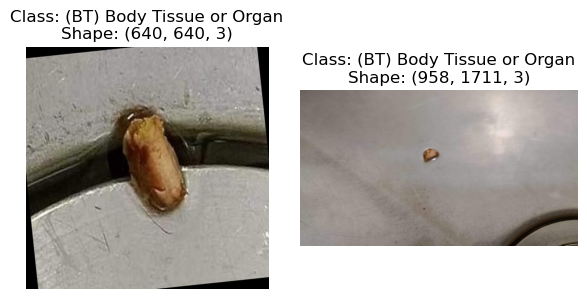

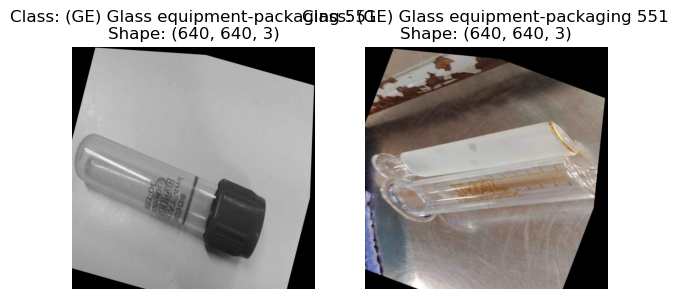

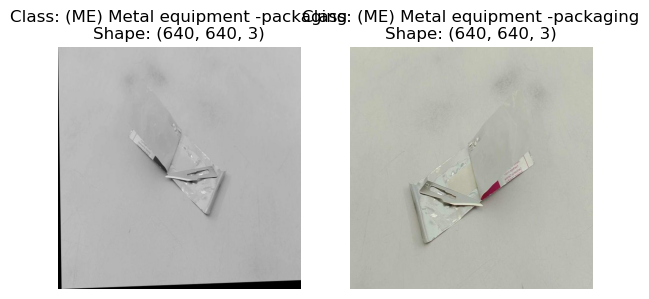

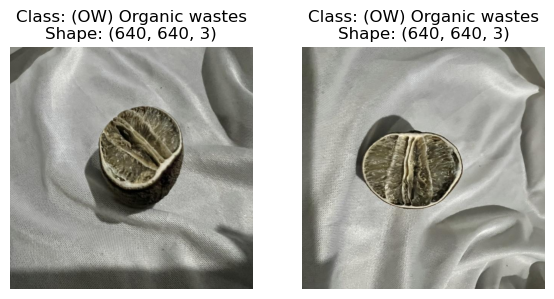

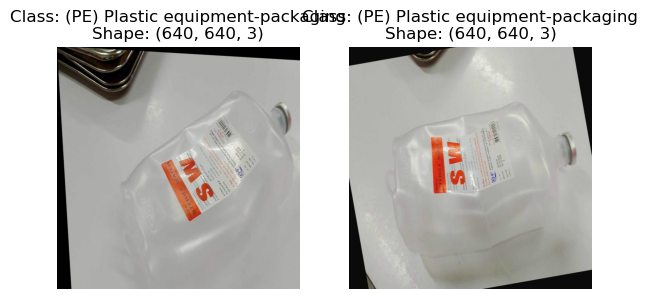

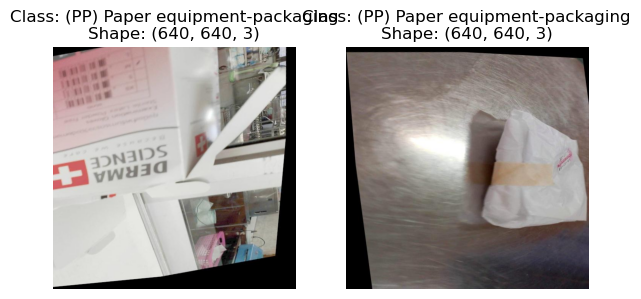

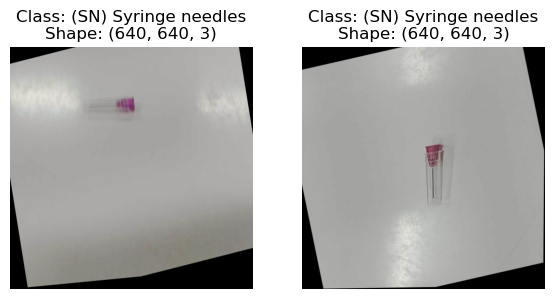

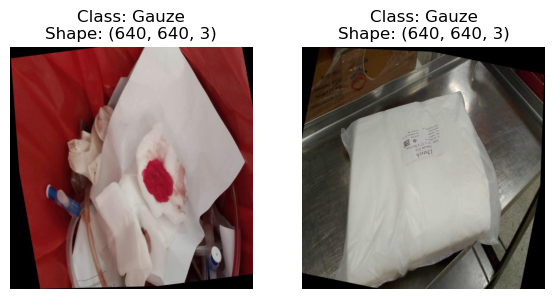

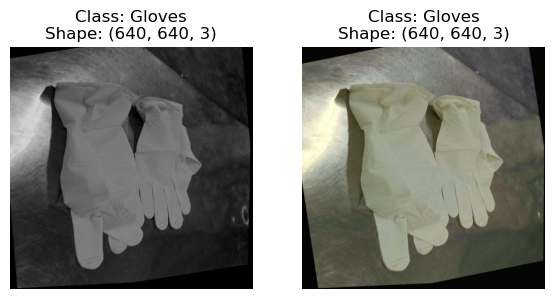

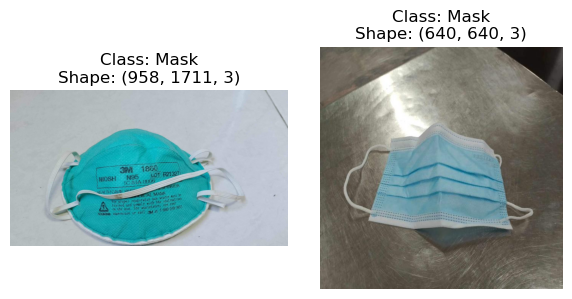

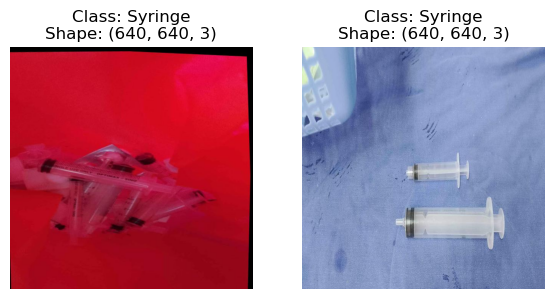

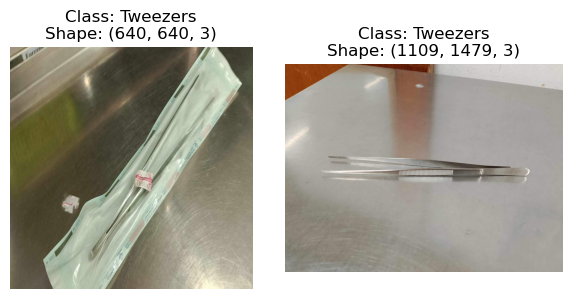

In [22]:
NUM_IMAGES = 2 

for label in CLASSES:
    total_images_class = list(Path(os.path.join(IMAGE_PATH, label)).glob("*/*.jpg"))
    if len(total_images_class) == 0:
        continue  

    k = min(NUM_IMAGES, len(total_images_class))
    total_selected = random.sample(total_images_class, k=k)  

    fig, ax = plt.subplots(1, k, figsize=(3*k, 3)) 
    if k == 1:
        ax = [ax] 

    for i, img_path in enumerate(total_selected):
        img_bgr = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        ax[i].imshow(img_rgb)
        ax[i].axis('off')
        ax[i].set_title(f'Class: {label}\nShape: {img_rgb.shape}')

    fig.tight_layout()
    plt.show()
    

    

In [23]:

IMAGE_PATH = Path("/Users/tanzinaa/Documents/python/Pharmaceutical and Biomedical Waste (PBW)")
CLASSES = sorted([c for c in os.listdir(IMAGE_PATH) if (IMAGE_PATH / c).is_dir()])

data = []

for label in CLASSES:
    class_path = IMAGE_PATH / label
    image_files = list(class_path.glob("*/*.jpg"))
    num_images = len(image_files)
    data.append({
        "class": label,
        "num_images": num_images,
        "quantity": num_images  
    })


df = pd.DataFrame(data)
csv_path = IMAGE_PATH / "waste_quantity.csv"
df.to_csv(csv_path, index=False)

print(df)


                                 class  num_images  quantity
0            (BT) Body Tissue or Organ         474       474
1   (GE) Glass equipment-packaging 551         551       551
2      (ME) Metal equipment -packaging         426       426
3                  (OW) Organic wastes         583       583
4     (PE) Plastic equipment-packaging         558       558
5       (PP) Paper equipment-packaging         457       457
6                 (SN) Syringe needles         513       513
7                                Gauze         510       510
8                               Gloves         543       543
9                                 Mask         529       529
10                             Syringe         473       473
11                            Tweezers         539       539


In [24]:
IMG_SIZE = (128, 128)
images = []
labels = []

for class_name in df['class']:
    folder_name = class_name.strip()
    class_path = IMAGE_PATH / folder_name

    if not class_path.exists():
        continue

    for img_path in class_path.glob("*/*.jpg"):
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, IMG_SIZE)
        images.append(img)
        labels.append(class_name)

X = np.array(images, dtype=np.float32) / 255.0
y_class = np.array(labels)

# Encode class labels
le = LabelEncoder()
y_encoded = le.fit_transform(y_class)

# Assign quantity based on image count per class
quantity_dict = dict(zip(df['class'], df['quantity']))
y_quantity = np.array([quantity_dict[label] for label in y_class])

print(f"Images: {X.shape}, Class labels: {y_encoded.shape}, Quantity labels: {y_quantity.shape}")



Images: (6156, 128, 128, 3), Class labels: (6156,), Quantity labels: (6156,)


In [25]:

def extract_hog_features(images):
    hog_features = []
    for img in images:
        features, _ = hog(
    img, 
    orientations=9, 
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    channel_axis=-1,       
    block_norm='L2-Hys',
    visualize=True
)
        hog_features.append(features)
    return np.array(hog_features)

print("Extracting HOG features...")
X_hog = extract_hog_features(X)
print("HOG feature shape:", X_hog.shape)



Extracting HOG features...
HOG feature shape: (6156, 8100)


In [26]:
X_train, X_test, y_train, y_test, q_train, q_test = train_test_split(
    X_hog, y_encoded, y_quantity, test_size=0.2, random_state=42, stratify=y_encoded
)


In [27]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print("\n Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

print("\n Accuracy:", accuracy_score(y_test, y_pred))



 Classification Report:
                                    precision    recall  f1-score   support

         (BT) Body Tissue or Organ       0.60      0.71      0.65        95
(GE) Glass equipment-packaging 551       0.84      0.77      0.81       110
   (ME) Metal equipment -packaging       0.97      0.86      0.91        85
               (OW) Organic wastes       0.86      0.87      0.87       117
  (PE) Plastic equipment-packaging       0.88      0.86      0.87       112
    (PP) Paper equipment-packaging       0.60      0.35      0.44        91
              (SN) Syringe needles       0.65      0.71      0.68       103
                             Gauze       0.82      0.85      0.84       102
                            Gloves       0.54      0.79      0.64       109
                              Mask       0.86      0.78      0.82       106
                           Syringe       0.57      0.63      0.60        94
                          Tweezers       0.69      0.56      0

In [30]:
lr = LinearRegression()
lr.fit(X_train, q_train)

q_pred = lr.predict(X_test)

print("\nWaste Quantity Prediction Example:")
for i in range(5):
    print(f"Predicted: {q_pred[i]:.2f}, Actual: {q_test[i]}")



Waste Quantity Prediction Example:
Predicted: 536.95, Actual: 529
Predicted: 583.45, Actual: 558
Predicted: 570.13, Actual: 583
Predicted: 496.22, Actual: 558
Predicted: 496.98, Actual: 457


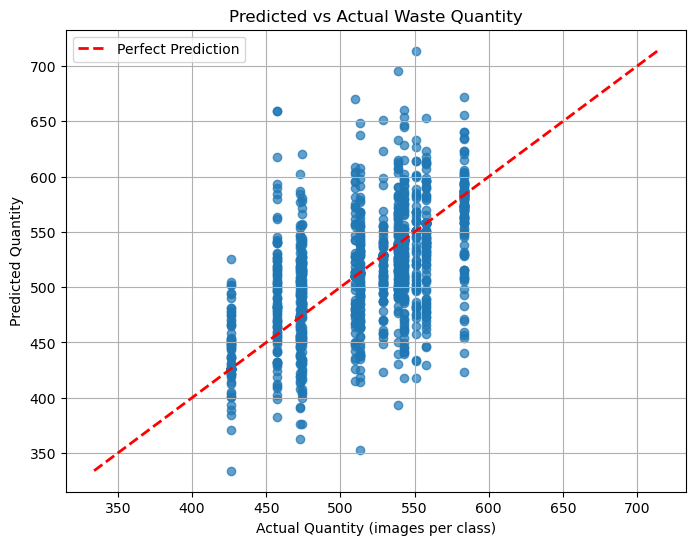

In [29]:

plt.figure(figsize=(8,6))
plt.scatter(q_test, q_pred, alpha=0.7)
plt.xlabel("Actual Quantity (images per class)")
plt.ylabel("Predicted Quantity")
plt.title("Predicted vs Actual Waste Quantity")
plt.grid(True)
min_val = min(q_test.min(), q_pred.min())
max_val = max(q_test.max(), q_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
plt.legend()
plt.show()
